# **Taller 6**


Angie Gutiérrez

Santiago Gómez


*Grupo 7*

In [159]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import dilation, erosion, opening, closing, skeletonize, thin, footprint_rectangle, disk, reconstruction, white_tophat
from scipy.ndimage import morphological_gradient
from skimage.filters import sobel_h, sobel_v, rank
from skimage import exposure, measure
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import clear_border, flood

## **Operadores de dilatación y erosión**

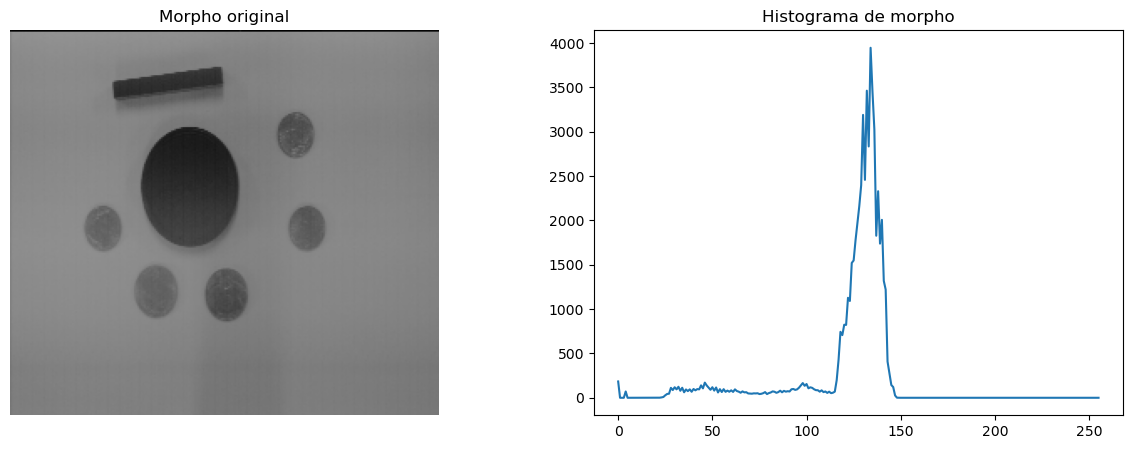

In [160]:
# Carga de morpho.png
morpho = cv2.imread('images/MORPHO.png', cv2.IMREAD_GRAYSCALE)

# Histograma de morpho
hist_morpho = cv2.calcHist([morpho], [0], None, [256], [0, 256])

# Visualización de morpho
fig_morpho, axis_morpho = plt.subplots(1, 2, figsize=(15, 5))
axis_morpho[0].imshow(morpho, cmap='gray', vmin= 0, vmax=255)
axis_morpho[0].set_title('Morpho original')
axis_morpho[0].axis('off')
axis_morpho[1].plot(hist_morpho)
axis_morpho[1].set_title('Histograma de morpho')
plt.show()

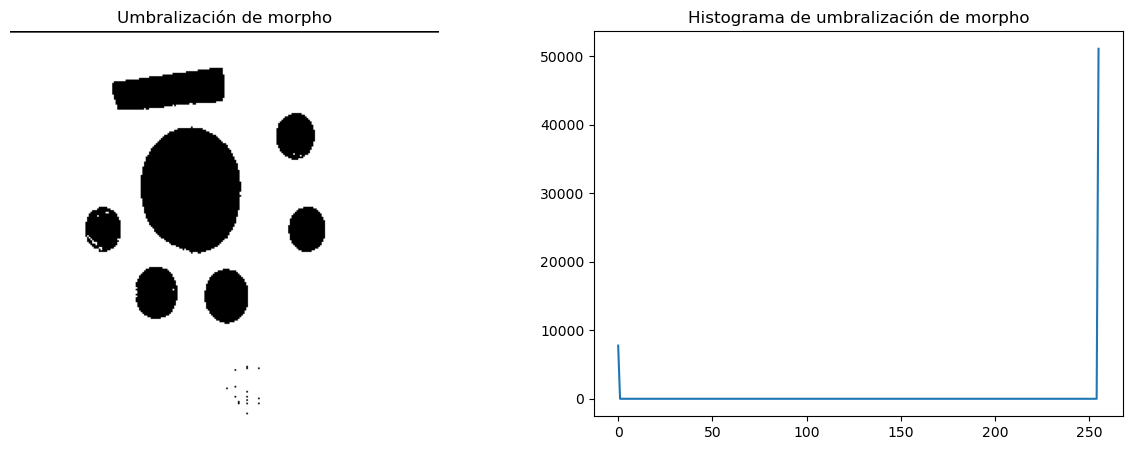

In [161]:
# Umbralización al rededor de 115
umbral= 115
thres_value, thres_morpho = cv2.threshold(morpho, umbral, 255, cv2.THRESH_BINARY)

# Histograma de morpho umbralizado
hist_morpho_rescaled = cv2.calcHist([thres_morpho], [0], None, [256], [0, 256])

# Visualización despues de la umbralización
fig_morpho_rescaled, axis_morpho_rescaled = plt.subplots(1, 2, figsize=(15, 5))
axis_morpho_rescaled[0].imshow(thres_morpho, cmap='gray', vmin=0, vmax=255)
axis_morpho_rescaled[0].set_title('Umbralización de morpho')
axis_morpho_rescaled[0].axis('off')
axis_morpho_rescaled[1].plot(hist_morpho_rescaled)
axis_morpho_rescaled[1].set_title('Histograma de umbralización de morpho')
plt.show()

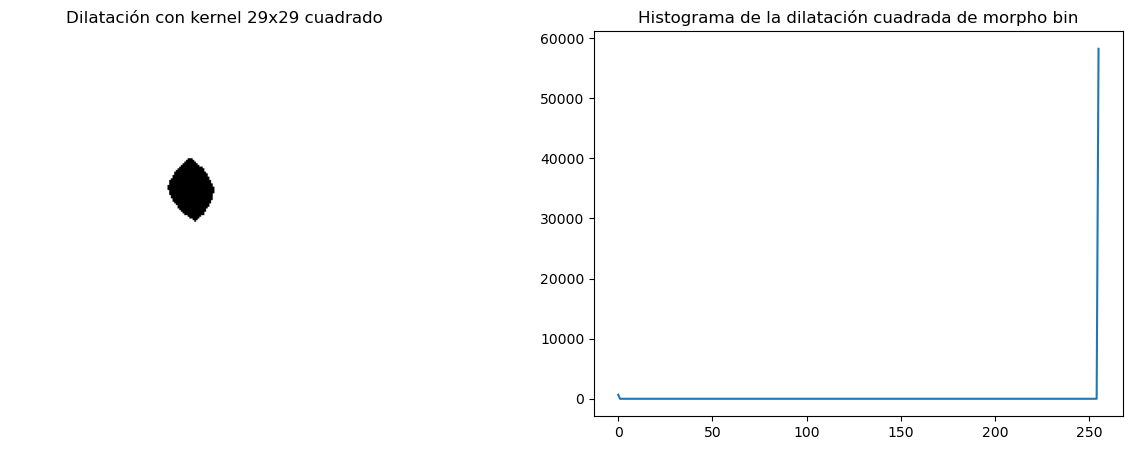

In [162]:
# Elemento estructurante o máscara cuadrada de 29x29
kernel_29 = np.ones((29,29), np.uint8)

# Dilatación (Expande el blanco, reduce el negro)
dilated_morpho = dilation(thres_morpho, kernel_29)

# Histograma de la dilatación
hist_dilated_morpho = cv2.calcHist([dilated_morpho], [0], None, [256], [0, 256])

fig_dilated_morpho, ax_dilated_morpho = plt.subplots(1, 2, figsize=(15, 5))

ax_dilated_morpho[0].imshow(dilated_morpho, cmap='gray', vmin=0, vmax=255)
ax_dilated_morpho[0].set_title('Dilatación con kernel 29x29 cuadrado')
ax_dilated_morpho[0].axis('off')
ax_dilated_morpho[1].plot(hist_dilated_morpho)
ax_dilated_morpho[1].set_title('Histograma de la dilatación cuadrada de morpho bin')

plt.show()

**¿Qué obtiene como resultado?**

Obtenemos una nueva imagen con las siguientes caracrerísticas:
* Todos los objetos oscuros que rodeaban al círculo central como las monedas y el rectángulo superior han desaparecido por completo. Sólo logró "sobrevivir" el círculo central más grandes.
* Sin embargo, el tamaño del sobreviviente se ha reducido drásticamente y su forma ha cambiado. Dado que ya no es un círculo perfecto, sino que adquirió una forma romboide o de diamante con bordes dentados.

Esto sucede porque cualquier objeto cuyo grosor sea menor al tamaño de la máscara (como las monedas y el rectángulo) es completamente consumido por el fondo claro. El círculo central, al tener un diámetro mayor a 29 píxeles, conserva su núcleo, pero su perímetro adopta características de la forma de la máscara cuadrada, perdiendo su curvatura original y reduciendo severamente su área.



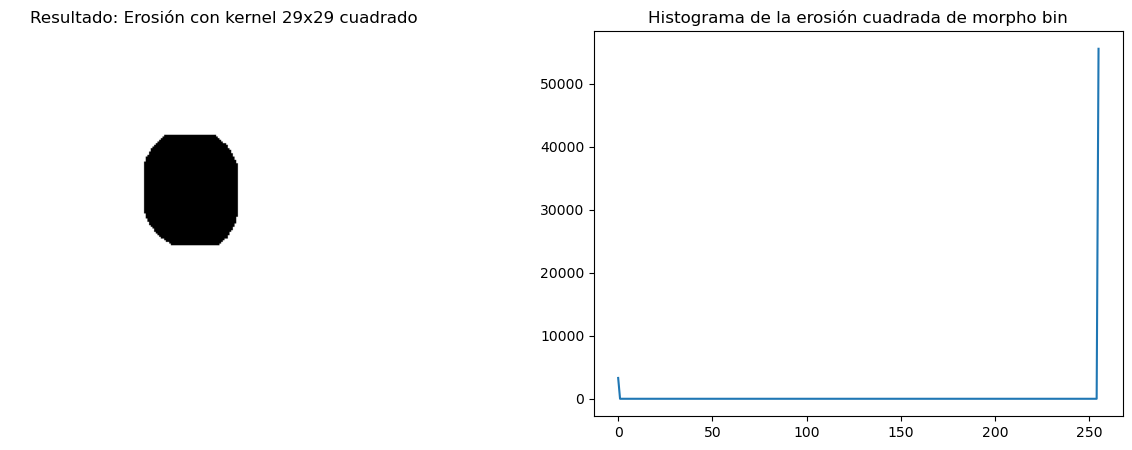

In [163]:
# Erosión de morpho (Erosiona el blanco, aumenta el negro)
erosion_morpho = erosion(dilated_morpho, kernel_29)

# Histograma de la erosión
hist_erosion_morpho = cv2.calcHist([erosion_morpho], [0], None, [256], [0, 256])

# Visualización de la erosión con mask cuadrada
fig_erosion_morpho, ax_erosion_morpho = plt.subplots(1, 2, figsize=(15, 5))

ax_erosion_morpho[0].imshow(erosion_morpho, cmap='gray', vmin=0, vmax=255)
ax_erosion_morpho[0].set_title('Resultado: Erosión con kernel 29x29 cuadrado')
ax_erosion_morpho[0].axis('off')
ax_erosion_morpho[1].plot(hist_erosion_morpho)
ax_erosion_morpho[1].set_title('Histograma de la erosión cuadrada de morpho bin')

plt.show()

**¿Cómo es el objeto obtenido con respecto al original?**

El objeto resultante ha sido exitosamente aislado de los elementos más pequeños, demostrando la eficacia de la apertura morfológica para filtrar por tamaño. Sin embargo, con respecto al original, el objeto conservado presenta una distorsión geométrica significativa. Su contorno circular ha sido reemplazado por bordes angulares característicos del elemento estructurante cuadrado ($29 \times 29$) utilizado en las iteraciones, evidenciando que estas transformaciones morfológicas modifican permanentemente las fronteras curvas de los objetos analizados

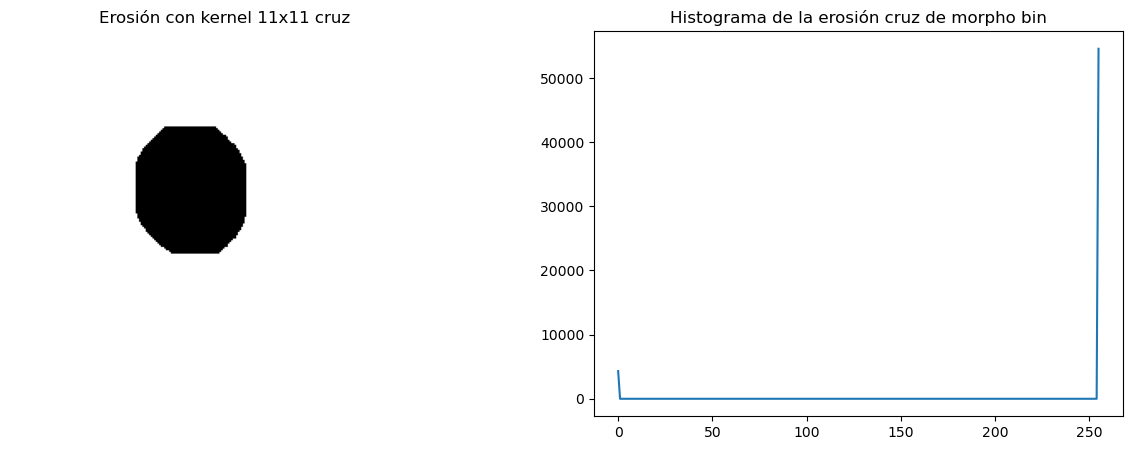

In [164]:
# Máscara 11 x 11 EN CRUZ
kernel_cruz_11 = cv2.getStructuringElement(cv2.MORPH_CROSS, (11, 11))

# Erosión con máscara cruz
erosion_cruz_morpho = erosion(erosion_morpho, kernel_cruz_11)

# Histograma de la erosión CRUZ
hist_erosion_cruz_morpho = cv2.calcHist([erosion_cruz_morpho], [0], None, [256], [0, 256])

# Visualización con mask cruz
fig_erosion_morpho11, ax_erosion_morpho11 = plt.subplots(1, 2, figsize=(15, 5))

ax_erosion_morpho11[0].imshow(erosion_cruz_morpho, cmap='gray', vmin=0, vmax=255)
ax_erosion_morpho11[0].set_title('Erosión con kernel 11x11 cruz')
ax_erosion_morpho11[0].axis('off')
ax_erosion_morpho11[1].plot(hist_erosion_cruz_morpho)
ax_erosion_morpho11[1].set_title('Histograma de la erosión cruz de morpho bin')

plt.show()

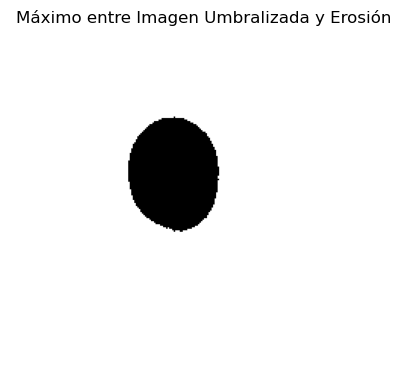

In [165]:
# Cálculo del máximo entre erosión 11x11 cruz y la imagen original umbralizada
img_max = np.maximum(thres_morpho, erosion_cruz_morpho)

# Visualización
plt.figure(figsize=(5, 5))
plt.imshow(img_max, cmap='gray')
plt.title('Máximo entre Imagen Umbralizada y Erosión')
plt.axis('off')
plt.show()

**¿Cómo es el resultado obtenido?**

El resultado permite recuperar los objetos pequeños que fueron filtrados intencionalmente en pasos previos, al mismo tiempo que suaviza y restaura la forma del objeto central que había sido distorsionado por las operaciones morfológicas sucesivas

### **Mismas operaciones sobre la imagen original**

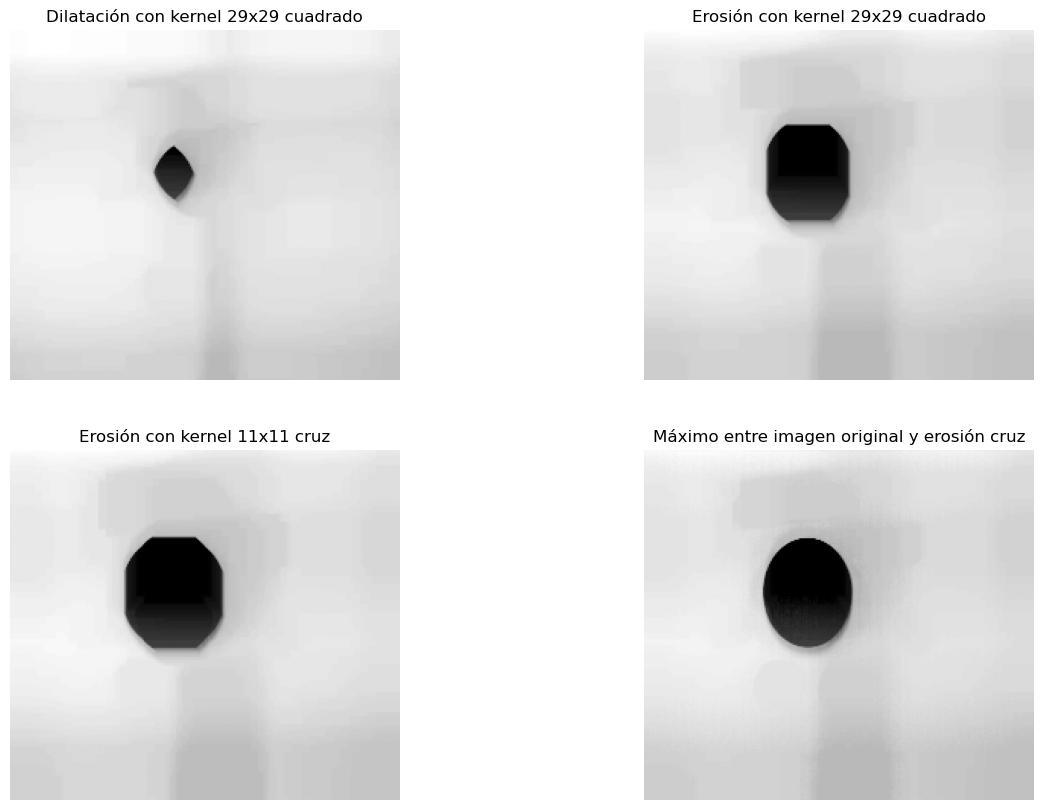

In [166]:
# Dilatación (Expande el blanco, reduce el negro)
dilated_morpho1 = dilation(morpho, footprint=footprint_rectangle((29,29)))

# Erosión de morpho (Erosiona el blanco, aumenta el negro)
erosion_morpho1 = erosion(dilated_morpho1, footprint=footprint_rectangle((29,29)))

# Erosión con máscara cruz
erosion_cruz_morpho1 = erosion(erosion_morpho1, kernel_cruz_11)

# Cálculo del máximo entre erosión 11x11 cruz y la imagen original
img_max1 = np.maximum(morpho, erosion_cruz_morpho1)

# Visualización de resultados con imagen original

fig_morpho_original, ax_morpho_original = plt.subplots(2, 2, figsize=(15, 10))

ax_morpho_original[0, 0].imshow(dilated_morpho1, cmap='gray')
ax_morpho_original[0, 0].set_title('Dilatación con kernel 29x29 cuadrado')
ax_morpho_original[0, 0].axis('off')
ax_morpho_original[0, 1].imshow(erosion_morpho1, cmap='gray')
ax_morpho_original[0, 1].set_title('Erosión con kernel 29x29 cuadrado')
ax_morpho_original[0, 1].axis('off')
ax_morpho_original[1, 0].imshow(erosion_cruz_morpho1, cmap='gray')
ax_morpho_original[1, 0].set_title('Erosión con kernel 11x11 cruz')
ax_morpho_original[1, 0].axis('off')
ax_morpho_original[1, 1].imshow(img_max1, cmap='gray')
ax_morpho_original[1, 1].set_title('Máximo entre imagen original y erosión cruz')
ax_morpho_original[1, 1].axis('off')
plt.show()

**¿Cómo funcionan las operaciones de erosión y de dilatación en imágenes en niveles de gris?**

En niveles de gris, la imagen se trata como una superficie topográfica tridimensional (donde el nivel de gris es la "altura" o elevación).

* La dilatación actúa como un filtro de máximo local, ya que el algoritmo superpone el elemento estructurante sobre un píxel y reemplaza el valor central por el valor de intensidad más alto (el píxel más claro) encontrado dentro de la vecindad. De hecho vemos como expande las regiones claras, elimina los detalles oscuros pequeños y ensancha los picos de intensidad.

* La erosión actúa como un filtro de mínimo local, ya que reemplaza el píxel central por el valor de intensidad más bajo (el píxel más oscuro) dentro de la vecindad. De hecho vemos como expande las regiones oscuras (como vemos al recuperar el tamaño del objeto central), elimina los detalles claros pequeños y profundiza los valles de intensidad.

**¿Cómo es el resultado obtenido sobre la imagen en niveles de gris, comparado con el resultado sobre la imagen binaria?**

En imágenes binarias, la morfología se basa en la teoría de conjuntos (intersecciones y uniones).

Primero vemos la diferencia en la preservación de la iluminación y gradientes.En el caso de la imagen binaria, el fondo era de un blanco puro y plano, pero el caso de niveles de gris, las operaciones morfológicas conservan las variaciones de iluminación del fondo.

Segundo, notamos la suavidad de los bordes, porque en el caso binario los bordes de los objetos se vuelven duros y propensos a verse dentados. Por otro lado, en escala de grises los bordes conservan su transición natural de intensidad, luciendo mucho más orgánicos y menos "recortados" artificialmente.

Tercero, evidenciamos que el objeto central oscuro resultante no es un "agujero" negro de un solo color puro (como en el binario), sino que mantiene un gradiente interno que hereda de la captura original.

Finalmente, se denota que la dilatación y erosión con el kernel cuadrado de 29x29 el fondo gris "invade" el objeto central creando bloques rectangulares de tonos medios a su alrededor, una especie de sombra con la forma geométrica del kernel que no ocurre de manera tan evidente en las imágenes binarias puras.

## **Gradiente morfológico**

$Gradiente(f) = Dilatacion(f) - Erosion(f)$

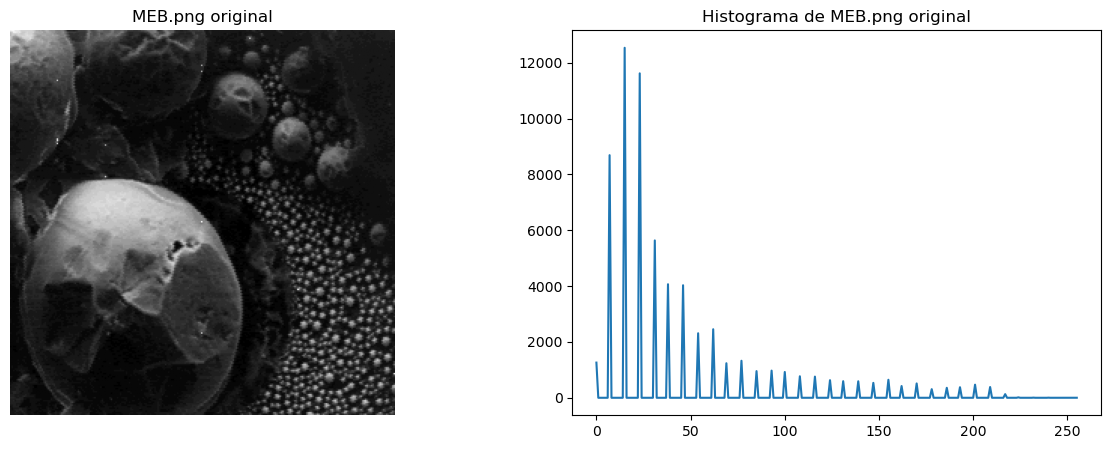

In [167]:
# Carga de meb.png
meb = cv2.imread('images/MEB.png', cv2.IMREAD_GRAYSCALE)

# Histograma de meb
hist_meb = cv2.calcHist([meb], [0], None, [256], [0, 256])

# Visualización de meb y su respectivo histograma
fig_meb, ax_meb = plt.subplots(1, 2, figsize=(15, 5))
ax_meb[0].imshow(meb, cmap='gray', vmin=0, vmax= 255)
ax_meb[0].set_title('MEB.png original')
ax_meb[0].axis('off')
ax_meb[1].plot(hist_meb)
ax_meb[1].set_title('Histograma de MEB.png original')
plt.show()

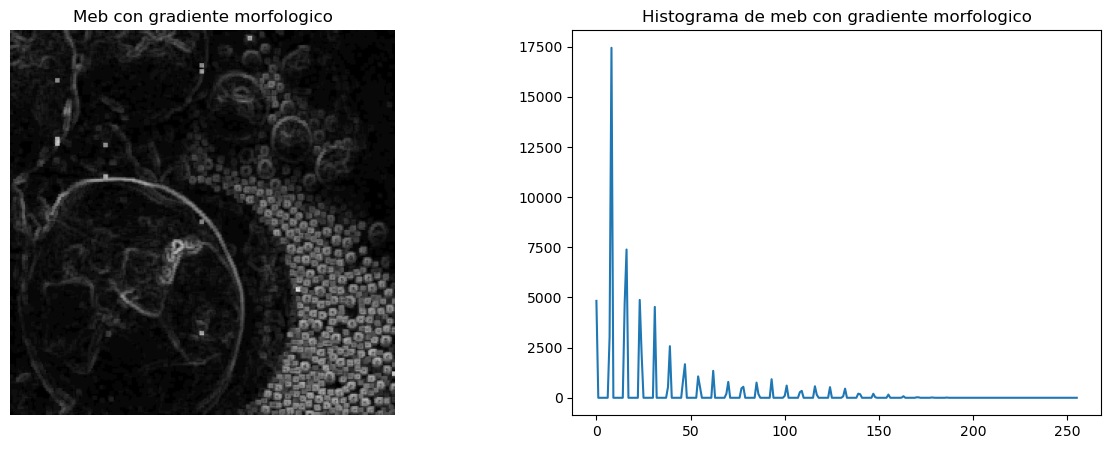

Maximo:  225
Minimo:  0


In [168]:
# Máscara 3x3
kernel3 = np.ones((3,3), np.uint8)

# Cálculo del gradiente morfológico (detector de bordes no lineal)
gm_meb = morphological_gradient(meb, footprint=kernel3)

# Histograma de gradiente morfologico
hist_gm = cv2.calcHist([gm_meb], [0], None, [256], [0, 256])

# Visualización del gradiente morfologico
fig_gm_meb , axes_gm_meb = plt.subplots(1, 2, figsize=(15,5))
axes_gm_meb[0].imshow(gm_meb, cmap='gray', vmin=0, vmax=255)
axes_gm_meb[0].set_title('Meb con gradiente morfologico')
axes_gm_meb[0].axis('off')
axes_gm_meb[1].plot(hist_gm)
axes_gm_meb[1].set_title('Histograma de meb con gradiente morfologico')
plt.show()

max= np.max(gm_meb)
min = np.min(gm_meb)
print('Maximo: ', max)
print('Minimo: ', min)

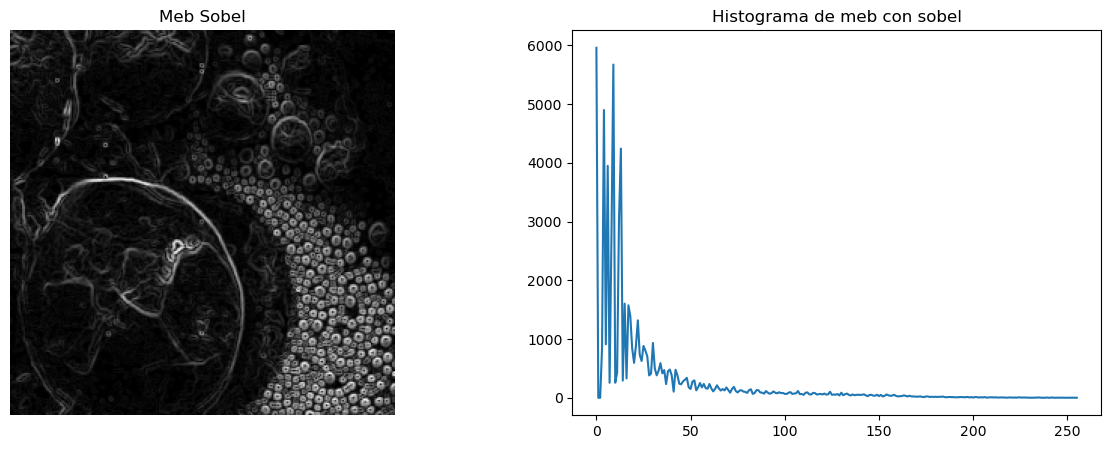

In [169]:
# Sobel horizontal
meb_sh = sobel_h(meb)
#Sobel vertical
meb_sv = sobel_v(meb)
# Gradiente de sobel
grad_sobel = np.sqrt(meb_sh**2 + meb_sv**2)

grad_sobel_cal = exposure.rescale_intensity(grad_sobel, out_range=(0, 255)).astype(np.uint8)

# Hist de sobel
hist_meb_sobel = cv2.calcHist([grad_sobel_cal], [0], None, [256], [0, 256])

# Visualización de meb con sobel
fig_meb_sobel, ax_meb_sobel = plt.subplots(1, 2, figsize=(15, 5))
ax_meb_sobel[0].imshow(grad_sobel_cal, cmap='gray')
ax_meb_sobel[0].set_title('Meb Sobel')
ax_meb_sobel[0].axis('off')
ax_meb_sobel[1].plot(hist_meb_sobel)
ax_meb_sobel[1].set_title('Histograma de meb con sobel')
plt.show()

**Comparación entre gradiente morfológico vs. norma del gradiente con Sobel**

El Gradiente Morfológico proporciona contornos precisos y delgados mediante la diferencia de extremos locales, pero es altamente susceptible al ruido y artefactos de alta frecuencia, conservando la naturaleza discreta del histograma.

En contraste, la Norma de Sobel, al integrar un suavizado derivativo, ofrece una detección de bordes más robusta frente al ruido, generando contornos más anchos y suaves, lo que se refleja en un histograma continuo debido al cálculo euclidiano de la magnitud.

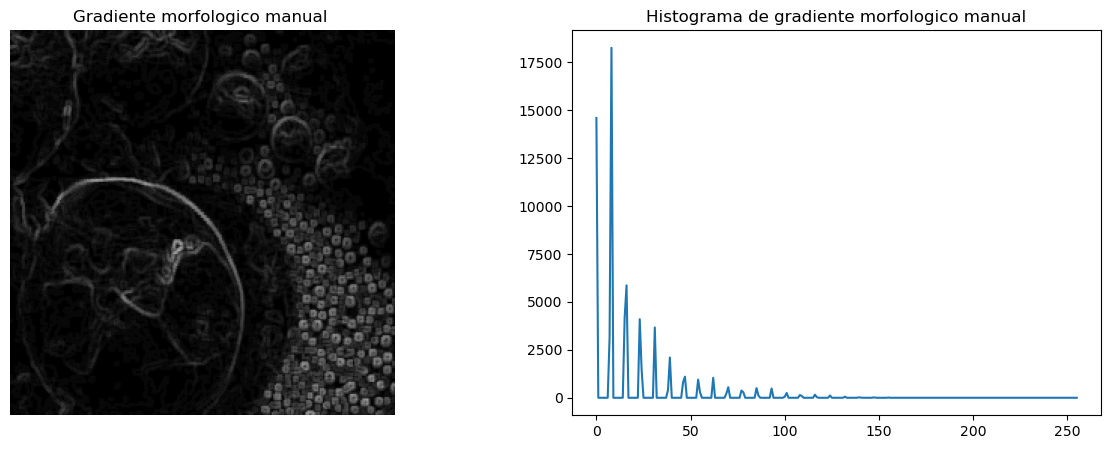

In [170]:
# Filtro mediano sobre meb original
meb_med = rank.median(meb, kernel3)

# Dilatación
dil_meb_med = dilation(meb_med, kernel3)

# Erosión
ero_meb_med = erosion(meb_med, kernel3)

# Gradiente morfologico manual
gradiente_manual = dil_meb_med.astype(np.int16) - ero_meb_med.astype(np.int16)
gradiente_manual = np.clip(gradiente_manual, 0, 255).astype(np.uint8)

# Histograma de gradiente manual
hist_gradiente_manual = cv2.calcHist([gradiente_manual], [0], None, [256], [0, 256])

# Visualización del gradiente manual
fig_gradiente_manual, ax_gradiente_manual = plt.subplots(1, 2, figsize=(15, 5))
ax_gradiente_manual[0].imshow(gradiente_manual , cmap='gray', vmin=0, vmax=255)
ax_gradiente_manual[0].set_title('Gradiente morfologico manual ')
ax_gradiente_manual[0].axis('off')
ax_gradiente_manual[1].plot(hist_gradiente_manual)
ax_gradiente_manual[1].set_title('Histograma de gradiente morfologico manual')
plt.show()

**¿Cómo es el resultado obtenido?**

El resultado demuestra ser una estrategia superior para imágenes con texturas complejas o ruido porque el filtro mediano actúa como una etapa de regularización espacial que previene la amplificación del ruido inherente a los operadores morfológicos derivados. Entonces la imagen tiene los bordes mucho más limpios y estructuralmente coherentes, sin sacrificar la nitidez característica de la morfología.

## **Operadores de apertura y cierre**

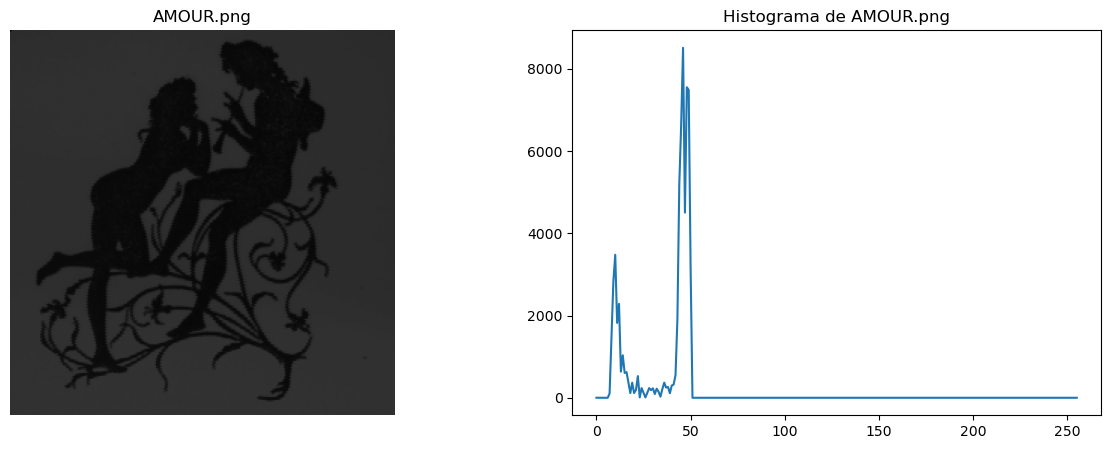

In [171]:
# Carga de amour
amour = cv2.imread('images/AMOUR.png', cv2.IMREAD_GRAYSCALE)

# Histograma de amour
hist_amour = cv2.calcHist([amour], [0], None, [256], [0, 256])

# Visualización de amour y su respectivo histograma
fig_amour, ax_amour = plt.subplots(1, 2, figsize=(15, 5))
ax_amour[0].imshow(amour, cmap='gray', vmin=0, vmax=255)
ax_amour[0].set_title('AMOUR.png')
ax_amour[0].axis('off')
ax_amour[1].plot(hist_amour)
ax_amour[1].set_title('Histograma de AMOUR.png')
plt.show()

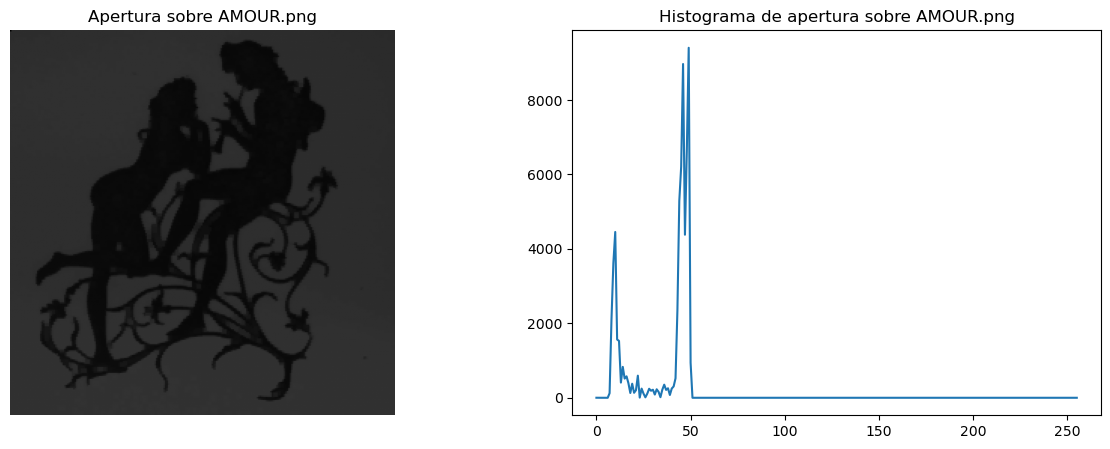

In [172]:
# Apertura
amour_op = opening(amour, footprint=footprint_rectangle((3, 3)))

# Histograma de apertura
hist_amour_op = cv2.calcHist([amour_op], [0], None, [256], [0, 256])

# Visualización de apertura sobre amour
fig_amour_op, ax_amour_op = plt.subplots(1, 2, figsize=(15, 5))
ax_amour_op[0].imshow(amour_op, cmap='gray', vmin=0, vmax=255)
ax_amour_op[0].set_title('Apertura sobre AMOUR.png')
ax_amour_op[0].axis('off')
ax_amour_op[1].plot(hist_amour_op)
ax_amour_op[1].set_title('Histograma de apertura sobre AMOUR.png')
plt.show()

**¿Qué partes fueron suprimidas?**

La apertura suprimió casi por completo wl punteado claro interior, homogeneizando el tono oscuro de las siluetas. Además, se eliminaron las regiones brillantes (picos de intensidad) cuyo tamaño es menor que la máscara de 5x5.

En el histograma de la apertura, notamos que los picos más oscuros (cerca de 10).Esto matemáticamente demuestra que los pequeños detalles claros fueron absorbidos por los tonos oscuros circundantes, validando la eliminación de la textura brillante.

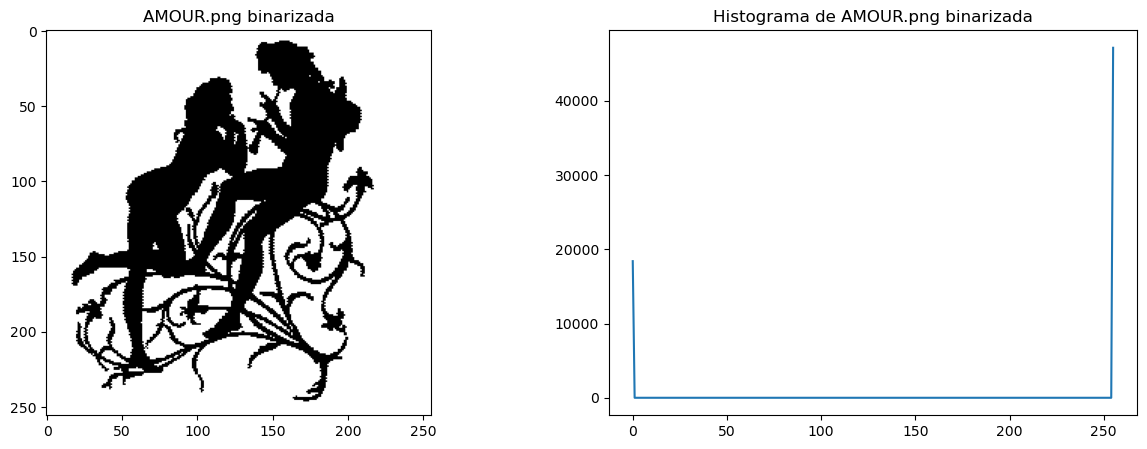

In [173]:
umbral2 = 35
# Binarización con umbral = 35
thres_value, thres_amour = cv2.threshold(amour, umbral2, 255, cv2.THRESH_BINARY)
thres_amour = thres_amour.astype(np.uint8)

# Histograma de amour binarizada
hist_amour_bin = cv2.calcHist([thres_amour], [0], None, [256], [0, 256])

# Visualización de la binarización
fig_amour_bin, ax_amour_bin = plt.subplots(1, 2, figsize=(15, 5))
ax_amour_bin[0].imshow(thres_amour, cmap='gray', vmin=0, vmax=255)
ax_amour_bin[0].set_title('AMOUR.png binarizada')
ax_amour_bin[1].plot(hist_amour_bin)
ax_amour_bin[1].set_title('Histograma de AMOUR.png binarizada')
plt.show()

In [174]:
# Diagonales 3x3
kernel_diag1 = np.empty((3,3), dtype=object)
kernel_diag1[:] = None
for i in range(3):
    for j in range(3):
        if i == j:
            kernel_diag1[i, j] = 1

kernel_diag2 = np.empty((3,3), dtype=object)
kernel_diag2[:] = None
for i in range(3):
    for j in range(3):
        if i + j == 2:
            kernel_diag2[i, j] = 1

# Horizontal 1x3
kernel_hor = np.array([[1, 1, 1]], dtype=object)

# Vertical 3x1
kernel_ver = np.array([[1], [1], [1]], dtype=object)

print(f'La diagonal identidad es: \n {kernel_diag1} \n')
print(f'La diagonal antisimétrica es: \n {kernel_diag2} \n')
print(f'El kernel horizontal es: \n {kernel_hor} \n')
print(f'El kernel vertical es: \n {kernel_ver} \n')

La diagonal identidad es: 
 [[1 None None]
 [None 1 None]
 [None None 1]] 

La diagonal antisimétrica es: 
 [[None None 1]
 [None 1 None]
 [1 None None]] 

El kernel horizontal es: 
 [[1 1 1]] 

El kernel vertical es: 
 [[1]
 [1]
 [1]] 



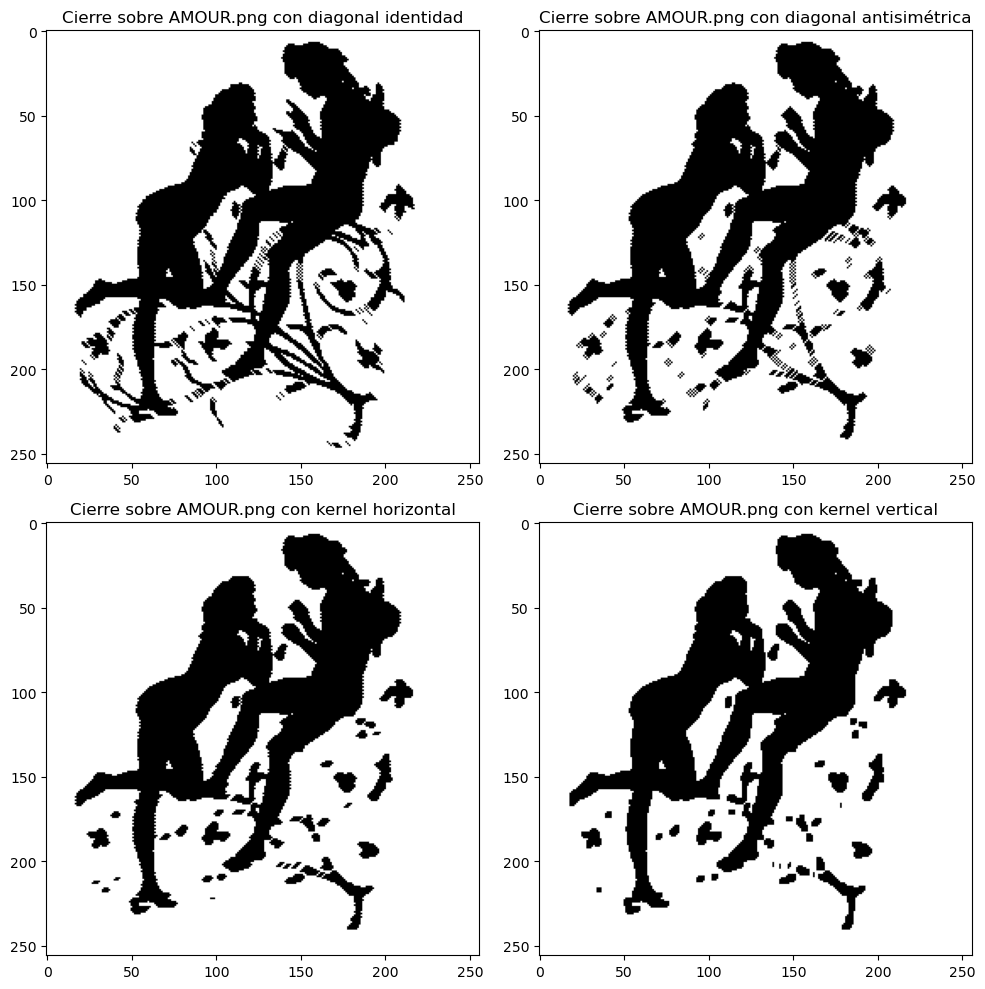

In [175]:
# Cierre sobre amour binarizada mediante 4 máscaras
amour_cierre1 = closing(thres_amour, kernel_diag1)
amour_cierre2 = closing(amour_cierre1, kernel_diag2)
amour_cierre3 = closing(amour_cierre2, kernel_hor)
amour_cierre4 = closing(amour_cierre3, kernel_ver)

# Visualización de amour con cierre
fig_amour_cierre, ax_amour_cierre = plt.subplots(2, 2, figsize=(10, 10))
ax_amour_cierre[0, 0].imshow(amour_cierre1, cmap='gray', vmin=0, vmax=255)
ax_amour_cierre[0, 0].set_title('Cierre sobre AMOUR.png con diagonal identidad')
ax_amour_cierre[0, 1].imshow(amour_cierre2, cmap='gray', vmin=0, vmax=255)
ax_amour_cierre[0, 1].set_title('Cierre sobre AMOUR.png con diagonal antisimétrica')
ax_amour_cierre[1, 0].imshow(amour_cierre3, cmap='gray', vmin=0, vmax=255)
ax_amour_cierre[1, 0].set_title('Cierre sobre AMOUR.png con kernel horizontal')
ax_amour_cierre[1, 1].imshow(amour_cierre4, cmap='gray', vmin=0, vmax=255)
ax_amour_cierre[1, 1].set_title('Cierre sobre AMOUR.png con kernel vertical')
fig_amour_cierre.tight_layout()
plt.show()

**¿Cuál es el efecto obtenido?**

El efecto obtenido es la consolidación de las formas oscuras principales (los personajes), rellenando exitosamente su textura interna. Sin embargo, debido al uso sucesivo de máscaras lineales en diferentes orientaciones, las estructuras finas (como el diseño floral inferior) sufrieron una distorsión geométrica severa, fusionándose en bloques sólidos rectangulares y perdiendo su delicada topología original.

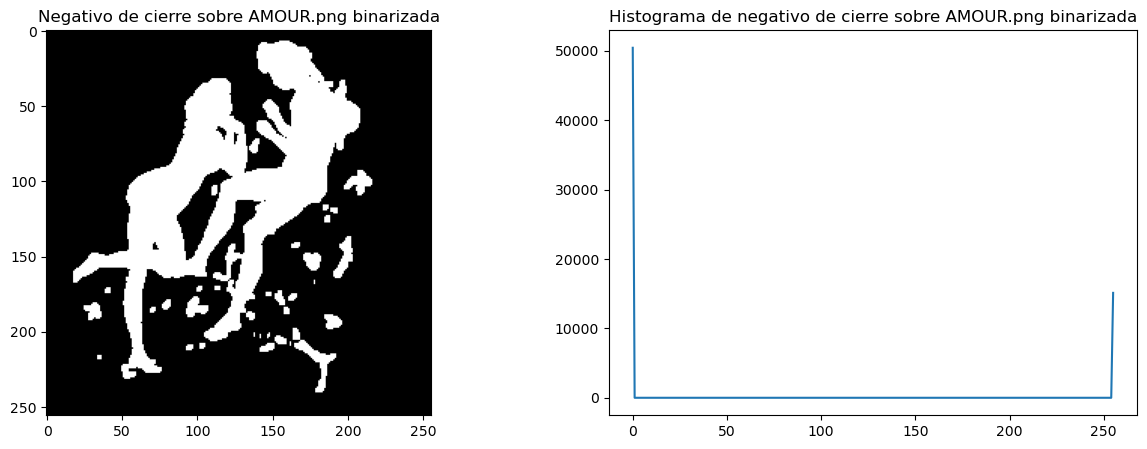

In [176]:
# Negativo de cierre
amour_cierre_neg = cv2.bitwise_not(amour_cierre4)

#Histograma del neg
hist_amour_cierre_neg = cv2.calcHist([amour_cierre_neg], [0], None, [256], [0, 256])

# Visualización del neg y su hist
fig_amour_cierre_neg, ax_amour_cierre_neg = plt.subplots(1, 2, figsize=(15, 5))
ax_amour_cierre_neg[0].imshow(amour_cierre_neg, cmap='gray', vmin=0, vmax=255)
ax_amour_cierre_neg[0].set_title('Negativo de cierre sobre AMOUR.png binarizada')
ax_amour_cierre_neg[1].plot(hist_amour_cierre_neg)
ax_amour_cierre_neg[1].set_title('Histograma de negativo de cierre sobre AMOUR.png binarizada')
plt.show()

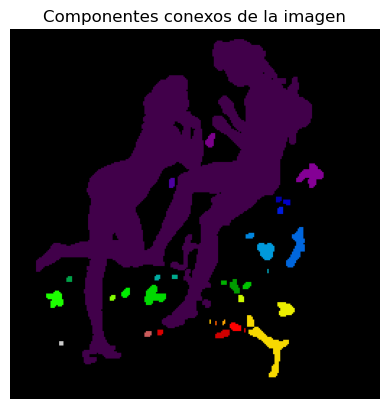

In [177]:
# Componentes conexos de la img
connected_components = label(amour_cierre_neg, background=0, connectivity=2)

# Visualización con mapa de colores
plt.imshow(connected_components, cmap='nipy_spectral')
plt.title('Componentes conexos de la imagen')
plt.axis('off')
plt.show()

In [178]:
# Escoger el componente conexo más grande
max_label = 0
max_area = 0
for lbl in np.unique(connected_components):
    if lbl == 0:
        continue

    area = np.sum(connected_components == lbl)
    if area > max_area:
        max_area = area
        max_label = lbl

print(f'El componente conexo más grande es el número {max_label} y tiene {max_area} píxeles')

El componente conexo más grande es el número 1 y tiene 13569 píxeles


**¿Cuál es el resultado?**

El resultado de aislar el componente conexo de mayor área es la segmentación exitosa de los personajes principales. Este paso actúa como un filtro espacial definitivo que descarta todos los artefactos geométricos y fragmentos desconectados que resultaron de las operaciones de cierre direccional previas, obteniendo una máscara sólida y limpia del sujeto de interés.

## **Etiquetado de objetos**

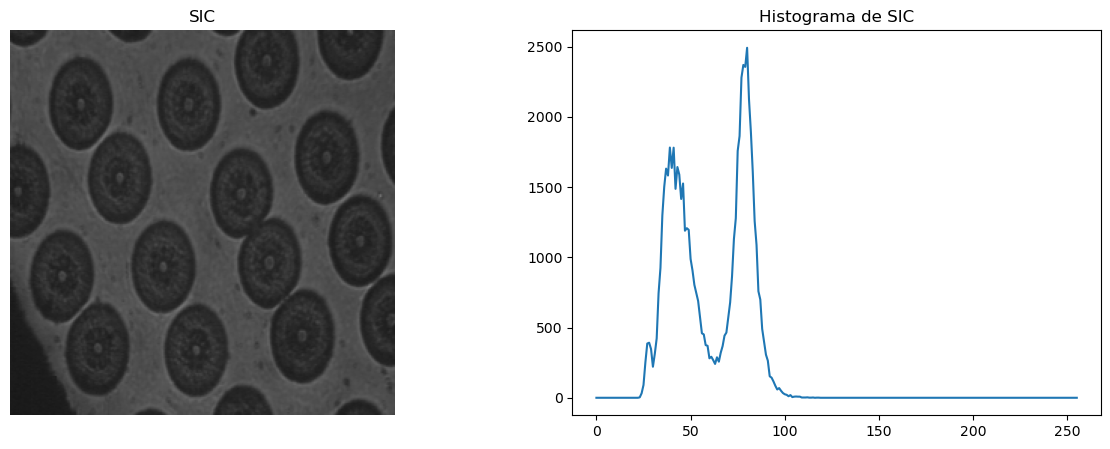

In [179]:
# Carga de sic
sic = cv2.imread('images/SIC.png', cv2.IMREAD_GRAYSCALE)

# Histograma de sic
hist_sic = cv2.calcHist([sic], [0], None, [256], [0, 256])

# Visualización de sic y su histograma
fig_sic, ax_sic = plt.subplots(1, 2, figsize=(15, 5))
ax_sic[0].imshow(sic, cmap='gray', vmin=0, vmax=255)
ax_sic[0].set_title('SIC')
ax_sic[0].axis('off')
ax_sic[1].plot(hist_sic)
ax_sic[1].set_title('Histograma de SIC')
plt.show()

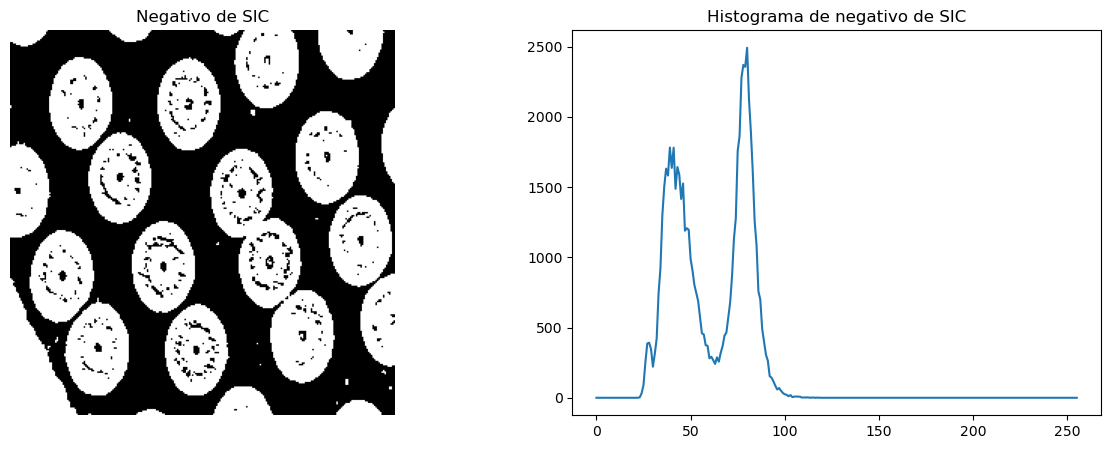

In [180]:
# Umbral entre 55 y 70
umbral3 = 55
umbral4 = 70
thres_value, thres_sic = cv2.threshold(sic, umbral3, umbral4, cv2.THRESH_BINARY)
thres_sic = thres_sic.astype(np.uint8)

# negativo de umbralizacion
sic_neg = cv2.bitwise_not(thres_sic)

# Histograma de neg
hist_sic_neg = cv2.calcHist([sic_neg], [0], None, [256], [0, 256])

# Visualización
fig_sic_neg, ax_sic_neg = plt.subplots(1, 2, figsize=(15, 5))
ax_sic_neg[0].imshow(sic_neg, cmap='gray')
ax_sic_neg[0].set_title('Negativo de SIC')
ax_sic_neg[0].axis('off')
ax_sic_neg[1].plot(hist_sic)
ax_sic_neg[1].set_title('Histograma de negativo de SIC')
plt.show()

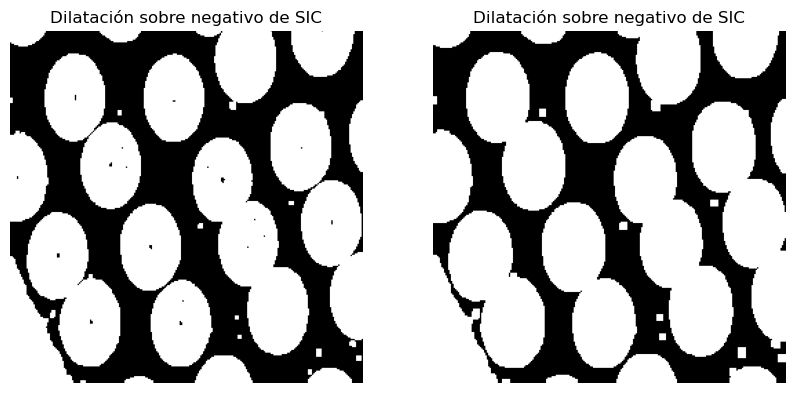

In [181]:
# Máscara en cruz 3x3
#kernel_cruz = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

# Dilataciones para rellenar
sic_dil1 = dilation(sic_neg, footprint=footprint_rectangle((3, 3)))
sic_dil2 = dilation(sic_dil1, footprint=footprint_rectangle((3, 3)))

# Visualización
fig_sic_dil, ax_sic_dil = plt.subplots(1, 2, figsize=(10, 5))
ax_sic_dil[0].imshow(sic_dil1, cmap='gray')
ax_sic_dil[0].set_title('Dilatación sobre negativo de SIC')
ax_sic_dil[0].axis('off')
ax_sic_dil[1].imshow(sic_dil2, cmap='gray')
ax_sic_dil[1].set_title('Dilatación sobre negativo de SIC')
ax_sic_dil[1].axis('off')
plt.show()

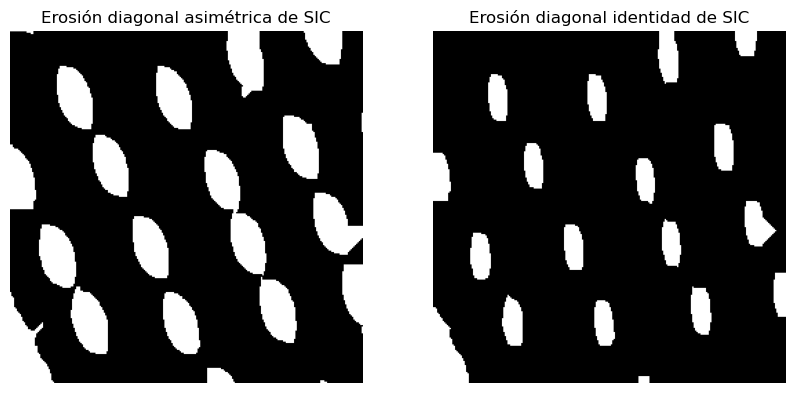

In [182]:
# Erosión agresiva para separar
# 10 veces con (/) y 6 veces con (\)
sic_sep1 = erosion(sic_dil2, footprint=kernel_diag2)
for i in range(10-1):
  sic_sep1 = erosion(sic_sep1, footprint=kernel_diag2)

sic_sep2 = erosion(sic_sep1, footprint=kernel_diag1)
for j in range(6-1):
  sic_sep2 = erosion(sic_sep2, footprint=kernel_diag1)

sic_sep1 = sic_sep1.astype(np.uint8)
sic_sep2 = sic_sep2.astype(np.uint8)

# Visualización de erosiones
fig_sic_erosion, ax_sic_erosion = plt.subplots(1, 2, figsize=(10, 5))
ax_sic_erosion[0].imshow(sic_sep1, cmap='gray')
ax_sic_erosion[0].set_title('Erosión diagonal asimétrica de SIC')
ax_sic_erosion[0].axis('off')
ax_sic_erosion[1].imshow(sic_sep2, cmap='gray')
ax_sic_erosion[1].set_title('Erosión diagonal identidad de SIC')
ax_sic_erosion[1].axis('off')
plt.show()

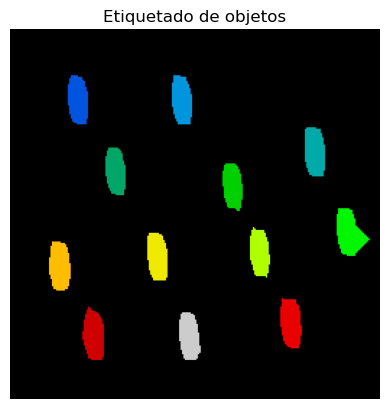

In [183]:
# connectivity=2 en skimage significa que considera vecinos horizontales, verticales y diagonales
labels = label(sic_sep2, background=0, connectivity=2) # Changed 'label' to 'sk_label'
labels_cleared = clear_border(labels)
n_cells_cleared = np.max(labels_cleared)

# Visualización de etiquetado
plt.imshow(labels_cleared, cmap='nipy_spectral')
plt.title('Etiquetado de objetos')
plt.axis('off')
plt.show()

In [184]:
# Cantidad de células
print(f'La cantidad de células es: {n_cells_cleared}')

La cantidad de células es: 17


**¿Cuántas células enteras fueron detectadas?**

El uso de la función clear_border garantizó un recuento objetivo de 17 objetos completamente interiores. Este número es mayor al esperado visualmente y revela un efecto secundario crítico de la morfología direccional agresiva. Es decir, las múltiples erosiones no solo lograron separar las células que se tocaban, sino que provocaron la sobre-segmentación de algunas células individuales, dividiéndolas en componentes conexos separados.

**¿Qué ocurre con el borde?**

Ocurre un fenómeno morfológico crítico que distorsiona fuertemente las células periféricas.

Al aplicar un total de 16 iteraciones de erosión (10 oblicuas y 6 ortogonales para separar las células), el fondo negro avanza agresivamente "comiéndose" a los objetos blancos. Por lo tanto, las células que tocan el borde son erosionadas desde el margen hacia adentro sin ninguna resistencia, provocando que se encojan de forma asimétrica, pierdan gran parte de su área o incluso desaparezcan por completo.


## **Imagen de distancia**

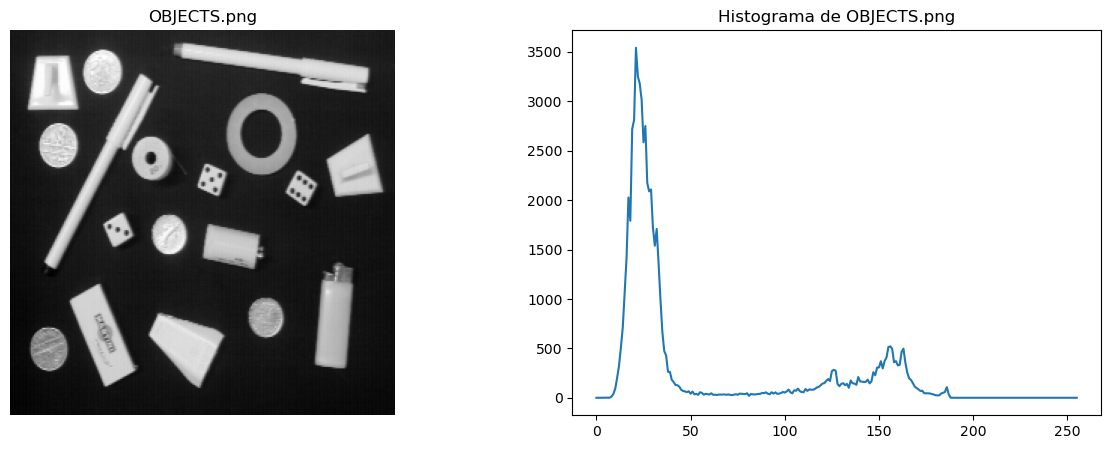

In [185]:
# Carga de objects.png
objects = cv2.imread('images/OBJECTS.png', cv2.IMREAD_GRAYSCALE)

# Histograma de objects
hist_objects = cv2.calcHist([objects], [0], None, [256], [0, 256])

# Visualización de objects y su hist
fig_objects, ax_objects = plt.subplots(1, 2, figsize=(15, 5))
ax_objects[0].imshow(objects, cmap='gray')
ax_objects[0].set_title('OBJECTS.png')
ax_objects[0].axis('off')
ax_objects[1].plot(hist_objects)
ax_objects[1].set_title('Histograma de OBJECTS.png')
plt.show()

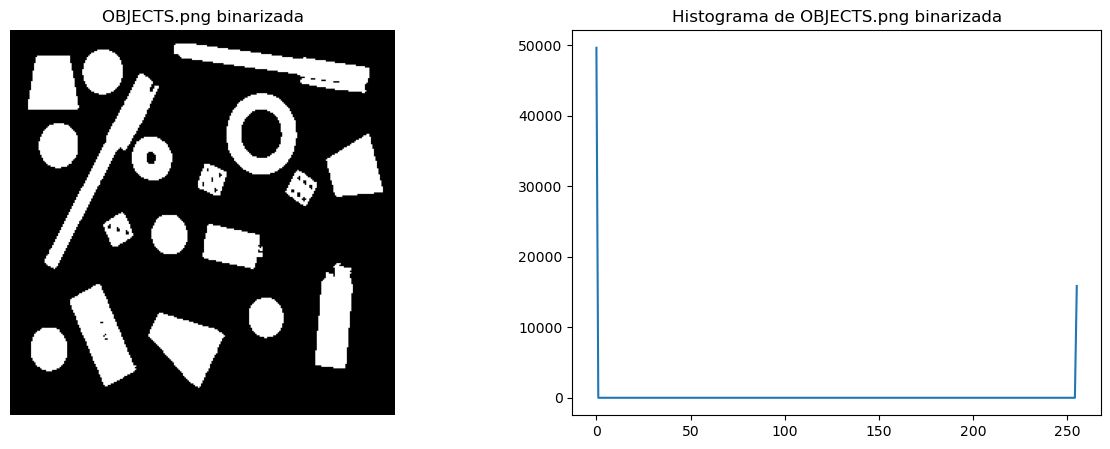

In [186]:
# Umbralización con umbral 70
umbral5 = 70

# Umbralización para separar los objetos del fondo
thres_value, thres_objects = cv2.threshold(objects, umbral5, 255, cv2.THRESH_BINARY)
thres_objects = thres_objects.astype(np.uint8)

# Histograma de objects
hist_objects = cv2.calcHist([thres_objects], [0], None, [256], [0, 256])

# Visualizacion de objects y su hist
fig_objects_rescaled, ax_objects_rescaled = plt.subplots(1, 2, figsize=(15, 5))
ax_objects_rescaled[0].imshow(thres_objects, cmap='gray')
ax_objects_rescaled[0].set_title('OBJECTS.png binarizada')
ax_objects_rescaled[0].axis('off')
ax_objects_rescaled[1].plot(hist_objects)
ax_objects_rescaled[1].set_title('Histograma de OBJECTS.png binarizada')
plt.show()

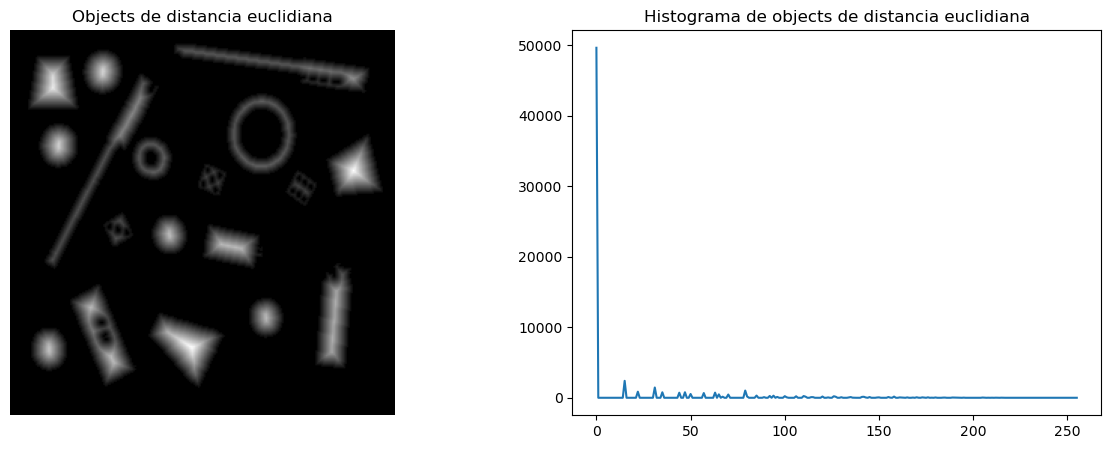

In [187]:
# Cálculo de objects de distancia euclidiana
objects_edm = distance_transform_edt(thres_objects)
objects_edm = (objects_edm / np.max(objects_edm)  * 255).astype(np.uint8)

# Histograma de objects de distancia euclidiana
hist_objects_edm = cv2.calcHist([objects_edm], [0], None, [256], [0, 256])

# Visualización de objects dist euclidiana y su respectivo hist
fig_objects_edm, ax_objects_edm = plt.subplots(1, 2, figsize=(15, 5))
ax_objects_edm[0].imshow(objects_edm, cmap='gray')
ax_objects_edm[0].set_title('Objects de distancia euclidiana')
ax_objects_edm[0].axis('off')
ax_objects_edm[1].plot(hist_objects_edm)
ax_objects_edm[1].set_title('Histograma de objects de distancia euclidiana')
plt.show()

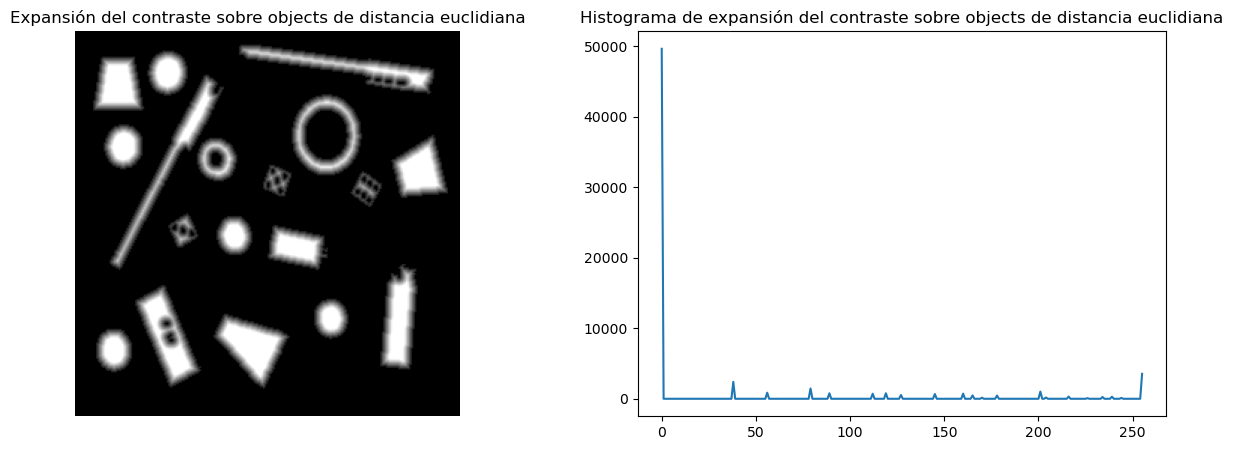

In [188]:
# Expansión del contraste sobre distancia euclidiana
rescaled_objects_edm = exposure.rescale_intensity(objects_edm, in_range=(0, 100), out_range=(0, 255)).astype(np.uint8)

# hist de expansión del contraste
hist_rescaled_objects_edm = cv2.calcHist([rescaled_objects_edm], [0], None, [256], [0, 256])

# Visualización de expansión del contraste sobre distancia euclidiana
fig_objects_edm_rescaled, ax_objects_edm_rescaled = plt.subplots(1, 2, figsize=(15, 5))
ax_objects_edm_rescaled[0].imshow(rescaled_objects_edm, cmap='gray')
ax_objects_edm_rescaled[0].set_title('Expansión del contraste sobre objects de distancia euclidiana')
ax_objects_edm_rescaled[0].axis('off')
ax_objects_edm_rescaled[1].plot(hist_rescaled_objects_edm)
ax_objects_edm_rescaled[1].set_title('Histograma de expansión del contraste sobre objects de distancia euclidiana')
plt.show()

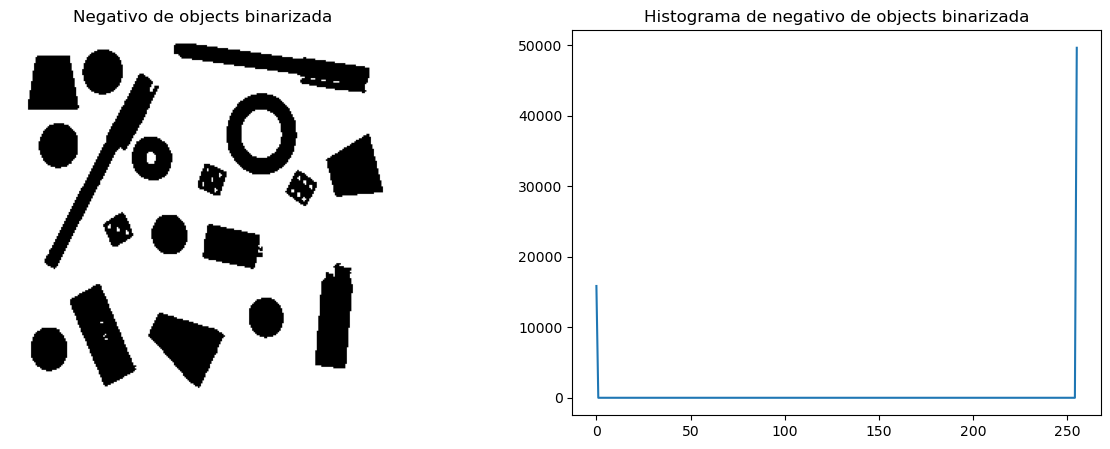

In [189]:
# Negativo de objects binarizada
objects_neg = cv2.bitwise_not(thres_objects)

# Hist de neg binarizada
hist_objects_neg = cv2.calcHist([objects_neg], [0], None, [256], [0, 256])

# Visualización de neg objects binarizada
fig_objects_neg, ax_objects_neg = plt.subplots(1, 2, figsize=(15, 5))
ax_objects_neg[0].imshow(objects_neg, cmap='gray')
ax_objects_neg[0].set_title('Negativo de objects binarizada')
ax_objects_neg[0].axis('off')
ax_objects_neg[1].plot(hist_objects_neg)
ax_objects_neg[1].set_title('Histograma de negativo de objects binarizada')
plt.show()

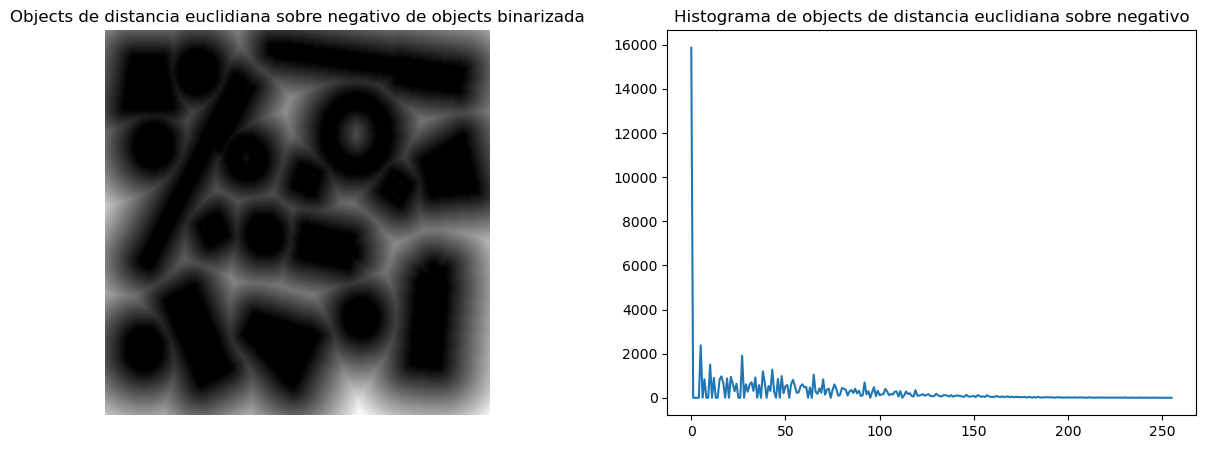

In [190]:
# Distancia euclidiana sobre neg binarizada
object_neg_edm = distance_transform_edt(objects_neg)
object_neg_edm = ( object_neg_edm / np.max(object_neg_edm) * 255).astype(np.uint8)

# Histograma de dist euclidiana sobre neg binarizada
hist_object_neg_edm = cv2.calcHist([object_neg_edm], [0], None, [256], [0, 256])

# Visualización de dist euclid sobre neg bin y su hist
fig_objects_neg_edm, ax_objects_neg_edm = plt.subplots(1, 2, figsize=(15, 5))
ax_objects_neg_edm[0].imshow(object_neg_edm, cmap='gray')
ax_objects_neg_edm[0].set_title('Objects de distancia euclidiana sobre negativo de objects binarizada')
ax_objects_neg_edm[0].axis('off')
ax_objects_neg_edm[1].plot(hist_object_neg_edm)
ax_objects_neg_edm[1].set_title('Histograma de objects de distancia euclidiana sobre negativo')
plt.show()

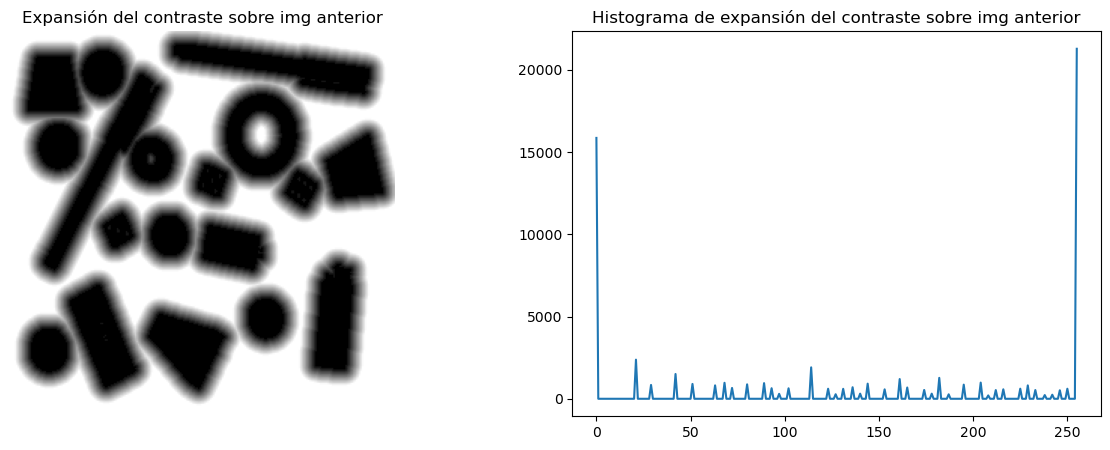

In [191]:
# Reescalado
rescaled_object_neg_edm = exposure.rescale_intensity(object_neg_edm, in_range=(0,60), out_range=(0, 255))
rescaled_object_neg_edm = rescaled_object_neg_edm.astype(np.uint8)

# Hist reescalado
hist_rescaled_objects_neg_edm = cv2.calcHist([rescaled_object_neg_edm], [0], None, [256], [0, 256])

# Visualización de rescalado de la anterior img
fig_rescaled_objects_neg_edm, ax_rescaled_objects_neg_edm = plt.subplots(1, 2, figsize=(15, 5))
ax_rescaled_objects_neg_edm[0].imshow(rescaled_object_neg_edm, cmap='gray')
ax_rescaled_objects_neg_edm[0].set_title('Expansión del contraste sobre img anterior')
ax_rescaled_objects_neg_edm[0].axis('off')
ax_rescaled_objects_neg_edm[1].plot(hist_rescaled_objects_neg_edm)
ax_rescaled_objects_neg_edm[1].set_title('Histograma de expansión del contraste sobre img anterior')
plt.show()

## **Esqueleto y adelgazamiento de una imagen**

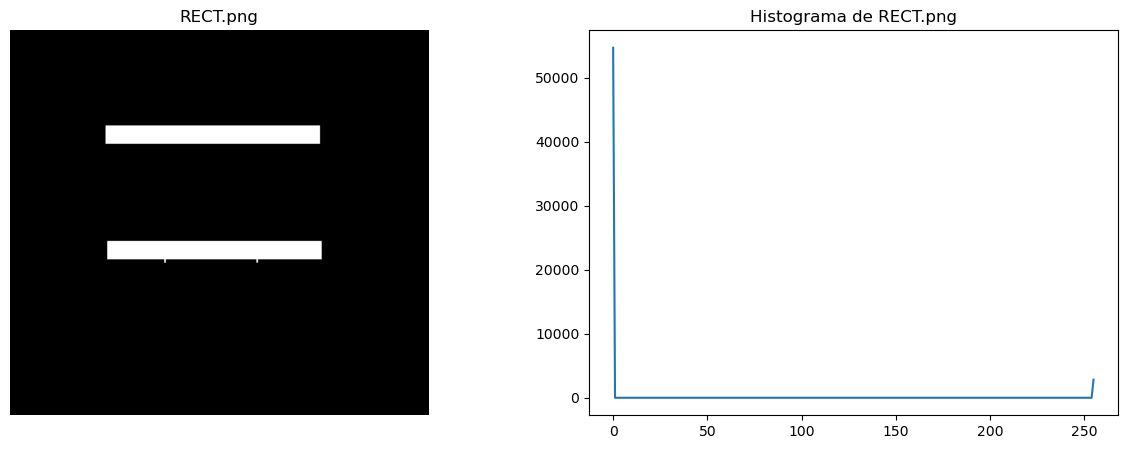

In [192]:
# Carga de rect.png
rect = cv2.imread('images/RECT.png', cv2.IMREAD_GRAYSCALE)

# Hist de rect
hist_rect = cv2.calcHist([rect], [0], None, [256], [0, 256])

# Visualización de rect y su hist
fig_rect, ax_rect = plt.subplots(1, 2, figsize=(15, 5))
ax_rect[0].imshow(rect, cmap='gray', vmin=0, vmax=255)
ax_rect[0].set_title('RECT.png')
ax_rect[0].axis('off')
ax_rect[1].plot(hist_rect)
ax_rect[1].set_title('Histograma de RECT.png')
plt.show()

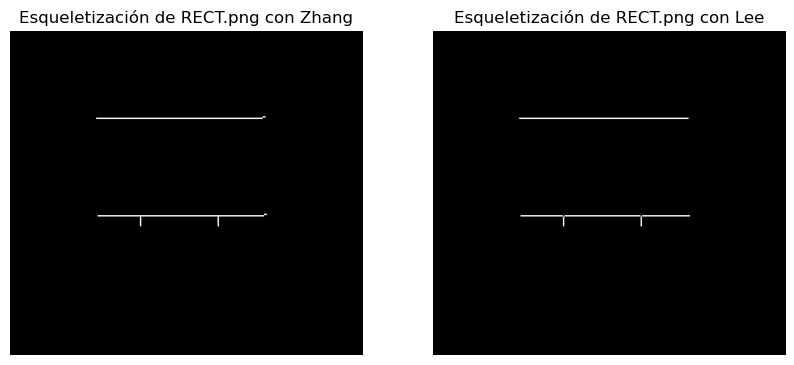

In [193]:
# Esqueletización de rect con zhang's method
rect_sk_z = skeletonize(rect, method='zhang')

# Esqueletización de rect con lee method
rect_sk_l = skeletonize(rect, method='lee')

# Visualización comparativa con cada método
fig_rect_sk, ax_rect_sk = plt.subplots(1, 2, figsize=(10, 5))
ax_rect_sk[0].imshow(rect_sk_z, cmap='gray')
ax_rect_sk[0].set_title('Esqueletización de RECT.png con Zhang')
ax_rect_sk[0].axis('off')
ax_rect_sk[1].imshow(rect_sk_l, cmap='gray')
ax_rect_sk[1].set_title('Esqueletización de RECT.png con Lee')
ax_rect_sk[1].axis('off')
plt.show()

**Comparación entre ambos métodos**

* Método de Zhang: Extrajo exitosamente la línea media de ambos rectángulos y en el rectángulo inferior, el algoritmo generó dos "espinas" o pequeñas ramas ortogonales hacia abajo que corresponden a esos defectos del borde.

* Método de Lee: También extrajo el eje central, pero es ligeramente más robusto en el manejo de las espinas.

De hecho, los resultados son casi idénticos en cuanto a la topología general, demostrando que ambos detectan correctamente la medial axis principal y caen en la misma "trampa" del ruido del borde.

**Explicación de cómo funcionan ambos algoritmos en términos generales**

* Algoritmo de Zhang-Suen ('zhang'): Es un algoritmo de dos sub-iteraciones, en cada una examina la vecindad $3\times3$ de cada píxel del contorno del objeto, evalúa un conjunto de condiciones lógicas estrictas para marcar la eliminación de estos hasta que ningún píxel cambie. Es un estándar muy rápido y eficaz para adelgazar caracteres y trazos.
* Algoritmo de Lee ('lee'):  Es un algoritmo famoso por su algoritmo de esqueletización tridimensional (3D) para imágenes volumétricas, su adaptación a 2D se enfoca profundamente en el concepto de conectividad y preservación de puntos finales (end-points) usando el número de Euler.

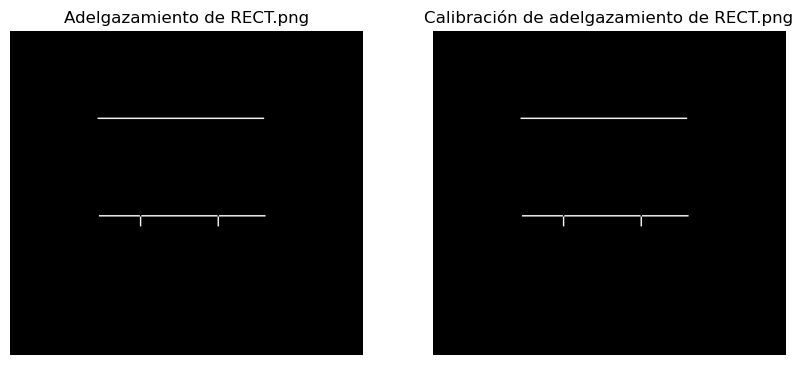

In [194]:
# Adelgazamiento de rect
rect_th = thin(rect)

# Calibración de adelgazamiento de rec
rect_th_rescaled = exposure.rescale_intensity(rect_th, in_range=(0, 100), out_range=(0, 255)).astype(np.uint8)

# Visualización de adelgazamiento y su calibración
fig_rect_th, ax_rect_th = plt.subplots(1, 2, figsize=(10, 5))
ax_rect_th[0].imshow(rect_th, cmap='gray')
ax_rect_th[0].set_title('Adelgazamiento de RECT.png')
ax_rect_th[0].axis('off')
ax_rect_th[1].imshow(rect_th_rescaled, cmap='gray')
ax_rect_th[1].set_title('Calibración de adelgazamiento de RECT.png')
ax_rect_th[1].axis('off')
plt.show()

**Compare el resultado con los de la esqueletización.**

* Similitud: Ambos operadores lograron extraer una representación filiforme (de 1 píxel de grosor) de los rectángulos originales. De igual manera, ambos demostraron ser exactamente igual de sensibles a las irregularidades del borde. El ruido en el borde inferior del segundo rectángulo provocó que tanto la esqueletización como el adelgazamiento generaran las mismas dos "espinas" o ramas falsas hacia abajo.

* Diferencia Teórica: En el caso de la esqueletización se busca matemáticamente el Eje Medial (Medial Axis Transform) y se intenta encontrar el lugar geométrico de los centros de todos los círculos tangentes a los bordes de la figura. Por otro lado, el adelgazamiento es un proceso morfológico puramente iterativo basado en transformaciones Hit-or-Miss (Acierto o Fallo). Su objetivo es erosionar los píxeles del contorno capa por capa utilizando un conjunto de máscaras estructurantes diseñadas específicamente para no romper la conectividad local (preservar el número de Euler), hasta que no se puedan quitar más píxeles.



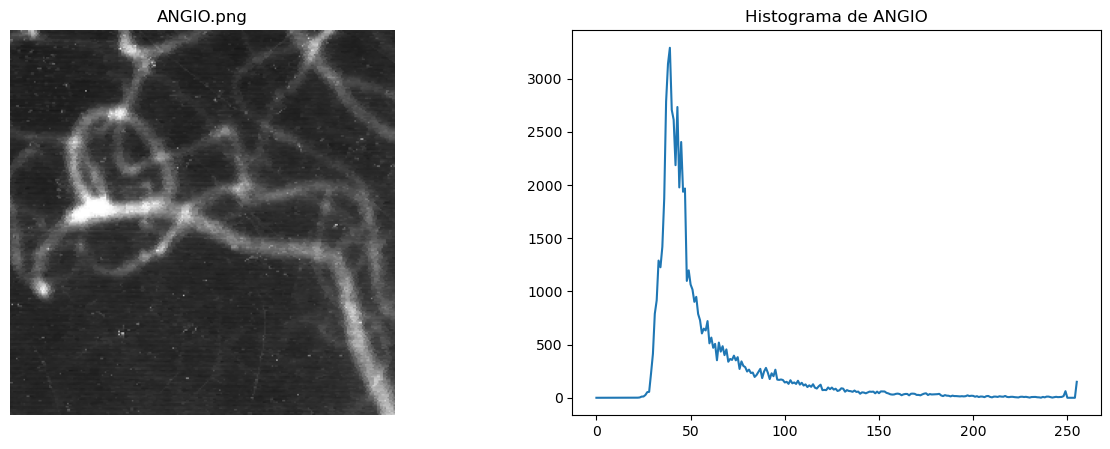

In [195]:
# Carga de angio.png
angio = cv2.imread('images/ANGIO.png', cv2.IMREAD_GRAYSCALE)

# Histograma de angio
hist_angio = cv2.calcHist([angio], [0], None, [256], [0, 256])

# Visualización de angio y su respectivo hist
fig_angio, ax_angio = plt.subplots(1, 2, figsize=(15, 5))
ax_angio[0].imshow(angio, cmap='gray', vmin=0, vmax=255)
ax_angio[0].set_title('ANGIO.png')
ax_angio[0].axis('off')
ax_angio[1].plot(hist_angio)
ax_angio[1].set_title('Histograma de ANGIO')
plt.show()

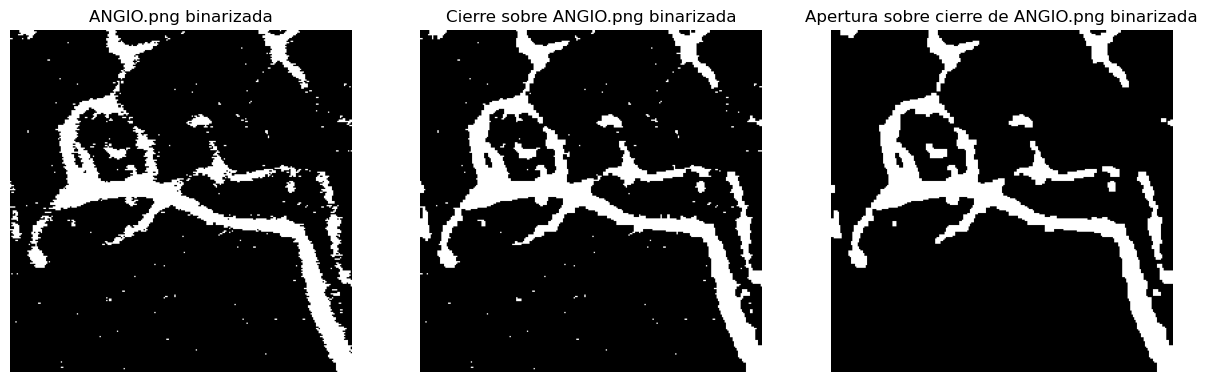

In [196]:
# Umbralización con otsu sobre angio
thres_value, thres_angio = cv2.threshold(angio, 100, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# Cierre de angio otsu
closing_angio  = closing(thres_angio, footprint=footprint_rectangle((3,3)))

# Apertura de angio otsu
opening_angio = opening(closing_angio, footprint=footprint_rectangle((3,3)))

# Visualización de resultados
fig_angio_res, ax_angio_res = plt.subplots(1, 3, figsize=(15, 5))
ax_angio_res[0].imshow(thres_angio, cmap='gray', vmin=0, vmax=255)
ax_angio_res[0].set_title('ANGIO.png binarizada')
ax_angio_res[0].axis('off')
ax_angio_res[1].imshow(closing_angio, cmap='gray', vmin=0, vmax=255)
ax_angio_res[1].set_title('Cierre sobre ANGIO.png binarizada')
ax_angio_res[1].axis('off')
ax_angio_res[2].imshow(opening_angio, cmap='gray', vmin=0, vmax=255)
ax_angio_res[2].set_title('Apertura sobre cierre de ANGIO.png binarizada')
ax_angio_res[2].axis('off')
plt.show()

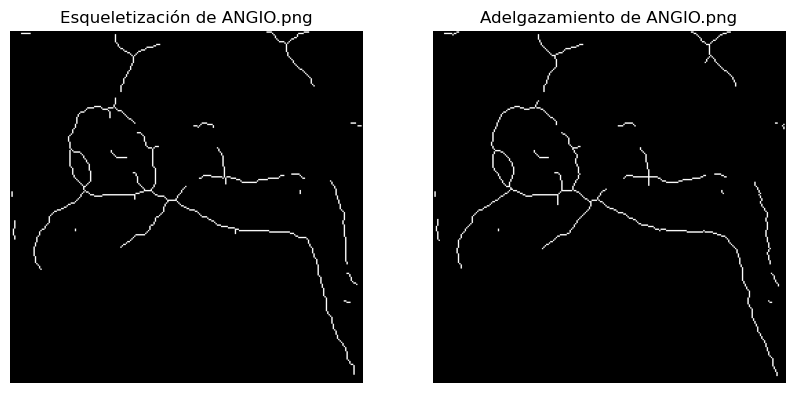

In [197]:
# Esqueletización con lee de angio
angio_sk = skeletonize(opening_angio, method='lee')

# Adelgazamiento de angio
angio_th = thin(opening_angio)

# Visualización de esqueletización vs adelgazamiento
fig_angio_sk_vs_th, ax_angio_sk_vs_th = plt.subplots(1, 2, figsize=(10, 5))
ax_angio_sk_vs_th[0].imshow(angio_sk, cmap='gray')
ax_angio_sk_vs_th[0].set_title('Esqueletización de ANGIO.png')
ax_angio_sk_vs_th[0].axis('off')
ax_angio_sk_vs_th[1].imshow(angio_th, cmap='gray')
ax_angio_sk_vs_th[1].set_title('Adelgazamiento de ANGIO.png')
ax_angio_sk_vs_th[1].axis('off')
plt.show()

**Compare los resultados de estos dos tratamientos**

Ambos métodos logran reducir las estructuras a su eje medial, facilitando el análisis topológico (cruces y bifurcaciones). No obstante, el adelgazamiento demuestra generar intersecciones ligeramente más limpias y es menos propenso a crear falsas ramificaciones cortas producto del ruido del contorno, lo que lo convierte en un método preferible para la extracción robusta del árbol vascular en aplicaciones médicas.

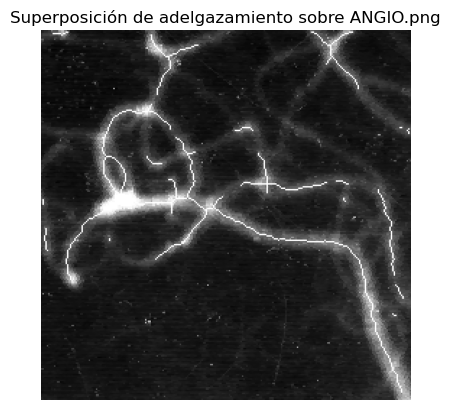

In [198]:
# Sobreponga la imagen adelgazada a la imagen angio.png (calculando el máximo entre las dos imágenes)
angio_th = (angio_th * 255).astype(np.uint8)
angio_superpuesta = np.maximum(angio, angio_th)

# Visualizaión de superposición
plt.imshow(angio_superpuesta, cmap='gray')
plt.title('Superposición de adelgazamiento sobre ANGIO.png')
plt.axis('off')
plt.show()

**Describa de forma cualitativa el resultado obtenido**

Principalmente, vemos que las líneas blancas generadas por el algoritmo de adelgazamiento se ubican con altísima precisión a lo largo del centro geométrico de los vasos sanguíneos. Además, se observa que estas líneas mantienen un grosor constante de un solo píxel, independientemente de si el vaso sanguíneo subyacente es muy ancho o muy estrecho.

Es decir, el resultado demuestra una excelente conservación de la estructura de la red. Vemos que las líneas blancas trazan fielmente los bucles (como la estructura circular prominente en el lado izquierdo), las curvas cerradas y las bifurcaciones (uniones en "Y"), conectando el sistema sin romper su continuidad lógica.

Finalmente, se nota que algunos vasos muy tenues o el ruido de fondo granulado de la imagen original no tienen una línea superpuesta. Esto indica que el paso previo de umbralización de Otsu y filtrado morfológico (cierre y apertura) fue efectivo para descartar el ruido y concentrar el análisis topológico únicamente en las estructuras vasculares principales.

## **Ejercicio de síntesis taller 6**

### **Ejercicio 1**

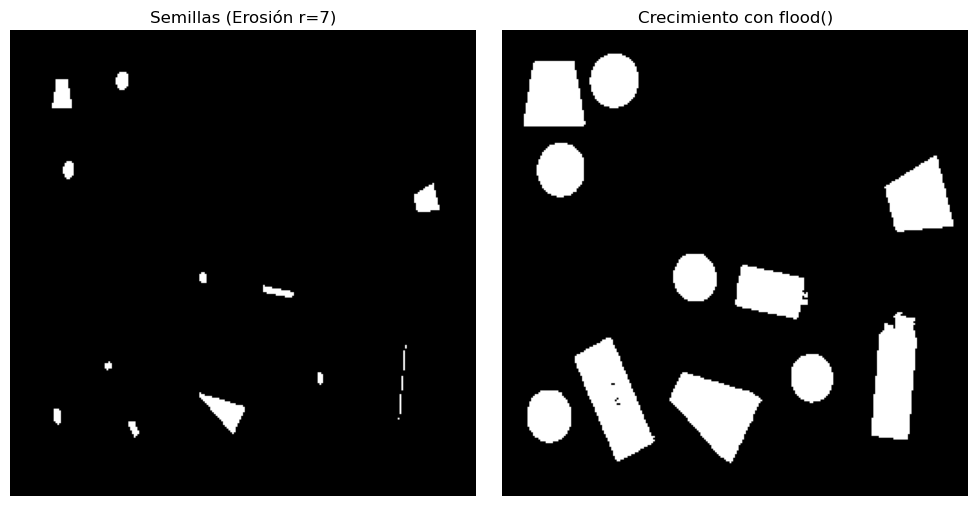

In [199]:
# thres_objects ya está umbralizada
mascara_original = thres_objects > 0


mascara_original_uint8 = mascara_original.astype(np.uint8) * 255

# Un disco de radio 7 nos da un diámetro de 15 píxeles
kernel_15 = disk(10)
semillas = erosion(mascara_original, kernel_15)

# Preparar el lienzo para el resultado, también como uint8
resultado_crecimiento = np.zeros_like(mascara_original, dtype=np.uint8)

# Primero etiquetamos las semillas para poder ubicar cada objeto grueso por separado
labels_semillas = measure.label(semillas)

# Iteramos sobre cada objeto grueso que sobrevivió a la erosión
for region in measure.regionprops(labels_semillas):
    punto_semilla = tuple(region.coords[0])

    zona_inundada = flood(mascara_original, punto_semilla)
    # Convert boolean zona_inundada to uint8 for OpenCV compatibility
    zona_inundada_uint8 = zona_inundada.astype(np.uint8) * 255

    resultado_crecimiento = cv2.bitwise_or(resultado_crecimiento, zona_inundada_uint8)

# Visualizamos
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(semillas, cmap='gray')
ax[0].set_title('Semillas (Erosión r=7)')
ax[0].axis('off')

ax[1].imshow(resultado_crecimiento, cmap='gray')
ax[1].set_title('Crecimiento con flood()')
ax[1].axis('off')

plt.tight_layout()
plt.show()

### **Ejercicio 2**

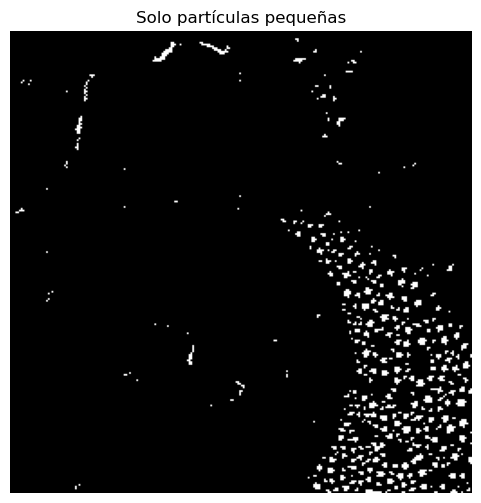

In [200]:
# 1) Binarización
_, mascara_base = cv2.threshold(meb, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2) Obtener semillas de objetos grandes
semillas_grandes = erosion(mascara_base > 0, disk(2))

# 3) Etiquetar semillas grandes
labels_grandes = measure.label(semillas_grandes, connectivity=2)

# 4) Reconstruir los objetos grandes por crecimiento de regiones
grandes_reconstruidos = np.zeros_like(mascara_base, dtype=np.uint8)

for etiqueta in range(1, labels_grandes.max() + 1):
    coords = np.argwhere(labels_grandes == etiqueta)
    
    if coords.size == 0:
        continue

    y, x = coords[0]
    zona = flood(mascara_base > 0, (y, x), connectivity=2)
    grandes_reconstruidos[zona] = 255

# 5) Eliminar las grandes y dejar solo las pequeñas
resultado_pequenas = cv2.bitwise_and(
    mascara_base,
    cv2.bitwise_not(grandes_reconstruidos)
)

# 6) Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(resultado_pequenas, cmap='gray')
plt.title('Solo partículas pequeñas')
plt.axis('off')
plt.show()